In [1]:
import numpy as np
import pandas as pd


In [2]:

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (16000, 2)
Test shape: (2000, 2)


In [4]:
train_df = train_df.drop_duplicates(
    subset="text"
).reset_index(drop=True)

print("Train shape after removing duplicates:", train_df.shape)

Train shape after removing duplicates: (15969, 2)


In [5]:
def clean_text(text):
    text = text.lower()
    text = text.strip()
    return text

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

In [6]:
X = train_df["text"]
y = train_df["label"]

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [8]:
X_test = test_df["text"]
y_test = test_df["label"]

Create TF-IDF Vectorize

In [9]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

What does this mean?

max_features=10000

→ Keep up to 10,000 most useful vocabulary features.

ngram_range=(1, 2)

→ Use both:

Fit TF-IDF only on training data

In [10]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [11]:
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

We do not do:

tfidf.fit_transform(X_test)

because would allow information from the test set to influence our feature representation.

Train Logistic Regression

In [12]:
lr_model = LogisticRegression(
    max_iter=1000
)

In [13]:
lr_model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [14]:
y_val_pred = lr_model.predict(X_val_tfidf)

In [15]:
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.8276293823038398


In [16]:
val_precision = precision_score(
    y_val,
    y_val_pred,
    average="macro"
)

val_recall = recall_score(
    y_val,
    y_val_pred,
    average="macro"
)

val_f1 = f1_score(
    y_val,
    y_val_pred,
    average="macro"
)

print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation Macro F1:", val_f1)

Validation Precision: 0.8613207882988986
Validation Recall: 0.6988274274783822
Validation Macro F1: 0.749078959219517


Macro F1 calculates F1 for each class and then takes their average.

This is useful because we don't want our evaluation to be dominated by the larger classes.

In [17]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
    )
)

              precision    recall  f1-score   support

     sadness       0.85      0.94      0.89       700
         joy       0.78      0.95      0.85       803
        love       0.83      0.46      0.59       195
       anger       0.89      0.74      0.81       323
        fear       0.87      0.70      0.77       290
    surprise       0.95      0.41      0.57        85

    accuracy                           0.83      2396
   macro avg       0.86      0.70      0.75      2396
weighted avg       0.84      0.83      0.82      2396



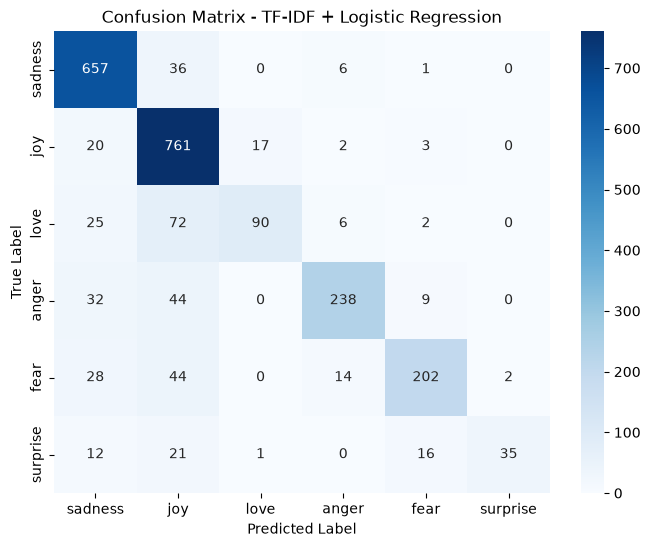

In [18]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ],
    yticklabels=[
        "sadness",
        "joy",
        "love",
        "anger",
        "fear",
        "surprise"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.show()

In [19]:
y_test_pred = lr_model.predict(X_test_tfidf)

In [20]:
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

print("Test Accuracy :", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall   :", test_recall)
print("Test Macro F1 :", test_f1)

Test Accuracy : 0.8295
Test Precision: 0.8512987559631777
Test Recall   : 0.6793813905368178
Test Macro F1 : 0.726827152560184


In [21]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [test_accuracy],
    "Precision": [test_precision],
    "Recall": [test_recall],
    "Macro F1": [test_f1]
})

baseline_results

,Model,Accuracy,Precision,Recall,Macro F1
0,TF-IDF + Logistic Regression,0.8295,0.851299,0.679381,0.726827


In [24]:
import os

os.makedirs("../models/baseline_model", exist_ok=True)

baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [test_accuracy],
    "Precision": [test_precision],
    "Recall": [test_recall],
    "Macro F1": [test_f1]
})

baseline_results.to_csv(
    "../models/baseline_model/baseline_results.csv",
    index=False
)